In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
print(df[df['TotalCharges'].str.strip() == ''].shape[0])

11


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
mask_zero_tenure = df['tenure'] == 0
df.loc[mask_zero_tenure, 'TotalCharges'] = df.loc[mask_zero_tenure, 'MonthlyCharges']

Ainda há NaN? 0


In [9]:
problemas_ids = df[mask_zero_tenure & df['tenure'].isna() == False].head(11)['customerID']
print(df[df['customerID'].isin(problemas_ids)][['tenure', 'MonthlyCharges', 'TotalCharges']])

    tenure  MonthlyCharges  TotalCharges
0        1           29.85         29.85
1       34           56.95       1889.50
2        2           53.85        108.15
3       45           42.30       1840.75
4        2           70.70        151.65
5        8           99.65        820.50
6       22           89.10       1949.40
7       10           29.75        301.90
8       28          104.80       3046.05
9       62           56.15       3487.95
10      13           49.95        587.45


In [10]:
df['avg_monthly_charge'] = df['TotalCharges'] / df['tenure']
df.loc[df['tenure'] == 0, 'avg_monthly_charge'] = df['MonthlyCharges']

In [11]:
df['tenure_group'] = pd.cut(df['tenure'], 
                            bins=[-1, 3, 12, 100], 
                            labels=['Novo (≤3m)', 'Regular (4-12m)', 'Leal (>12m)'])

In [12]:
servicos_extra = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

df['num_extra_services'] = df[servicos_extra].apply(lambda x: (x == 'Yes').sum(), axis=1)
df['is_bundle'] = (df['num_extra_services'] >= 2).astype(int)

In [13]:
print(df[['tenure', 'avg_monthly_charge', 'tenure_group', 'num_extra_services', 'is_bundle']].head(10))

   tenure  avg_monthly_charge     tenure_group  num_extra_services  is_bundle
0       1           29.850000       Novo (≤3m)                   1          0
1      34           55.573529      Leal (>12m)                   2          1
2       2           54.075000       Novo (≤3m)                   2          1
3      45           40.905556      Leal (>12m)                   3          1
4       2           75.825000       Novo (≤3m)                   0          0
5       8          102.562500  Regular (4-12m)                   3          1
6      22           88.609091      Leal (>12m)                   2          1
7      10           30.190000  Regular (4-12m)                   1          0
8      28          108.787500      Leal (>12m)                   4          1
9      62           56.257258      Leal (>12m)                   2          1


In [14]:
segmento_critico = df[
    (df['tenure'] <= 3) & 
    (df['avg_monthly_charge'] > 70) & 
    (df['is_bundle'] == 0)
]

In [15]:
print(f"Quantidade: {len(segmento_critico)} clientes")
print(f"Taxa de churn neste segmento: {segmento_critico['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Quantidade: 242 clientes
Taxa de churn neste segmento: 77.7%


In [16]:
novos_bundle = df[(df['tenure'] <= 3) & (df['is_bundle'] == 1)]
print(f"Novos com bundle - churn: {novos_bundle['Churn'].value_counts(normalize=True).get('Yes', 0)*100:.1f}%")

Novos com bundle - churn: 62.0%


In [18]:
leais = df[df['tenure'] > 12]
print(f"Clientes leais - churn: {leais['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

Clientes leais - churn: 17.1%


In [19]:
print(f"\nMédia geral de churn: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")


Média geral de churn: 26.5%


In [21]:
# Hipótese 1: Forma de pagamento influencia churn?
pagamento_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(pagamento_churn.sort_values(ascending=False))

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


In [23]:
# Hipótese 2: Clientes com paperless billing churn mais?
paperless_churn = df.groupby('PaperlessBilling')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(paperless_churn)

PaperlessBilling
No     16.330084
Yes    33.565092
Name: Churn, dtype: float64


In [24]:
# Hipótese 3: Tipo de contrato é o maior preditor?
contrato_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
print(contrato_churn.sort_values())

Contract
Two year           2.831858
One year          11.269518
Month-to-month    42.709677
Name: Churn, dtype: float64


In [25]:
def calcular_risco_cliente(row):
    risco = 0
    
    
    if row['Contract'] == 'Month-to-month':
        risco += 40
    elif row['Contract'] == 'One year':
        risco += 10
    
   
    if row['PaymentMethod'] == 'Electronic check':
        risco += 25
    
   
    if row['PaperlessBilling'] == 'Yes':
        risco += 10
    
   
    if row['tenure'] <= 3 and row['avg_monthly_charge'] > 70 and row['is_bundle'] == 0:
        risco += 25
    
    
    if row['tenure'] <= 3 and row['is_bundle'] == 0 and row['avg_monthly_charge'] <= 70:
        risco += 15
    
    return min(risco, 100)

df['risco_churn'] = df.apply(calcular_risco_cliente, axis=1)

print(df.groupby('Churn')['risco_churn'].describe())

from scipy.stats import pointbiserialr
corr, p_valor = pointbiserialr(df['risco_churn'], (df['Churn'] == 'Yes').astype(int))
print(f"Correlação point-biserial: {corr:.3f} (p={p_valor:.2e})")

df['nivel_risco'] = pd.cut(df['risco_churn'], bins=[0, 30, 60, 100], labels=['Baixo', 'Médio', 'Alto'])
print(df.groupby('nivel_risco', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100))

        count       mean        std  min   25%   50%   75%    max
Churn                                                            
No     5174.0  32.523193  26.163565  0.0  10.0  35.0  50.0  100.0
Yes    1869.0  62.902622  21.141517  0.0  50.0  65.0  75.0  100.0
Correlação point-biserial: 0.474 (p=0.00e+00)
nivel_risco
Baixo     6.774194
Médio    26.826029
Alto     54.090472
Name: Churn, dtype: float64


In [26]:
alto_risco = df[df['risco_churn'] > 60]
print(f"Clientes em alto risco: {len(alto_risco)}")
print(f"Churn real nesse grupo: {alto_risco['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"Isso representa {len(alto_risco[alto_risco['Churn'] == 'Yes'])} dos {len(df[df['Churn'] == 'Yes'])} churns totais")

Clientes em alto risco: 2078
Churn real nesse grupo: 54.1%
Isso representa 1124 dos 1869 churns totais


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

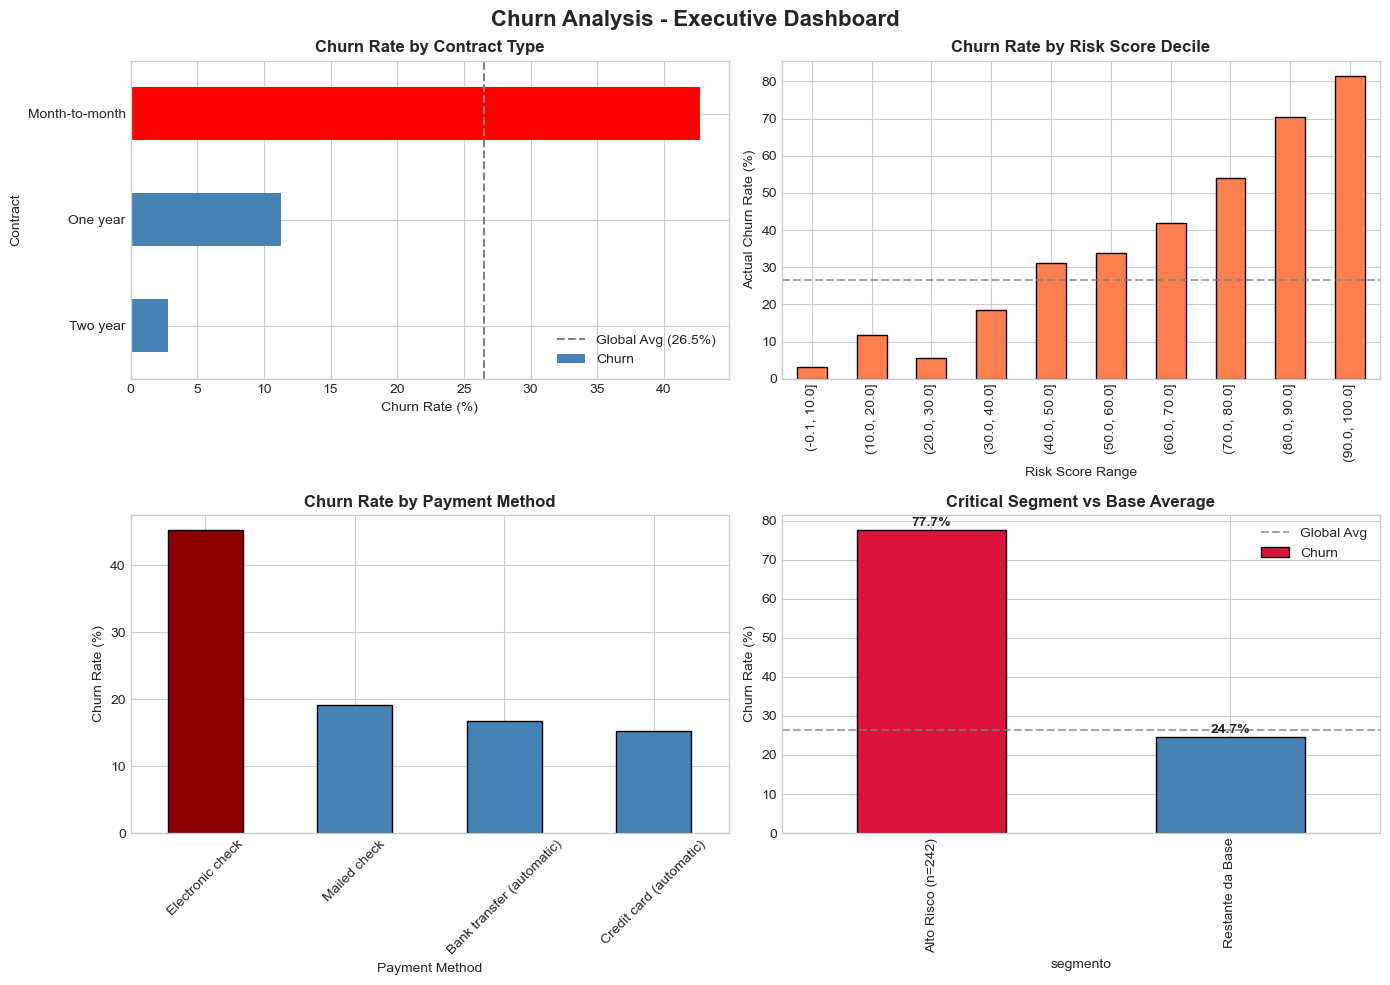

In [32]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("RdBu_r")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Analysis - Executive Dashboard', fontsize=16, fontweight='bold')


ax1 = axes[0, 0]
churn_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values()
colors = ['red' if c == 'Month-to-month' else 'steelblue' for c in churn_contract.index]
churn_contract.plot(kind='barh', ax=ax1, color=colors)
ax1.set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
ax1.set_xlabel('Churn Rate (%)')
ax1.axvline(x=df['Churn'].eq('Yes').mean()*100, linestyle='--', color='gray', label='Global Avg (26.5%)')
ax1.legend()


ax2 = axes[0, 1]
df_grouped = df.groupby(pd.cut(df['risco_churn'], bins=10), observed=False)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
df_grouped.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Churn Rate by Risk Score Decile', fontsize=12, fontweight='bold')
ax2.set_xlabel('Risk Score Range')
ax2.set_ylabel('Actual Churn Rate (%)')
ax2.axhline(y=26.5, linestyle='--', color='gray', alpha=0.7)


ax3 = axes[1, 0]
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
payment_colors = ['darkred' if p == 'Electronic check' else 'steelblue' for p in payment_churn.index]
payment_churn.plot(kind='bar', ax=ax3, color=payment_colors, edgecolor='black')
ax3.set_title('Churn Rate by Payment Method', fontsize=12, fontweight='bold')
ax3.set_xlabel('Payment Method')
ax3.set_ylabel('Churn Rate (%)')
ax3.tick_params(axis='x', rotation=45)


ax4 = axes[1, 1]
segmento_critico_mask = (df['tenure'] <= 3) & (df['avg_monthly_charge'] > 70) & (df['is_bundle'] == 0)
df['segmento'] = np.where(segmento_critico_mask, 'Alto Risco (n=242)', 'Restante da Base')
segment_churn = df.groupby('segmento')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
bars = segment_churn.plot(kind='bar', ax=ax4, color=['crimson', 'steelblue'], edgecolor='black')
ax4.set_title('Critical Segment vs Base Average', fontsize=12, fontweight='bold')
ax4.set_ylabel('Churn Rate (%)')
ax4.axhline(y=26.5, linestyle='--', color='gray', alpha=0.7, label='Global Avg')
ax4.legend()


for i, bar in enumerate(bars.patches):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_dashboard_executivo.png', dpi=300, bbox_inches='tight')
plt.show()